In [4]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import pandas as pd
import geopandas as gpd
import numpy as np

In [ ]:

# =========================================================
# CONFIG
# =========================================================

BASE = r"C:\Tesis\Códigos"

ESTADOS = {
    "IA": {
        "resultados": os.path.join(BASE, "resultados_eeuu", "ia_sys"),
        "comunas": os.path.join(BASE, "DataEEUU", "data_eeuu_procesada", "comunas_ia.xlsx"),
        "ady": os.path.join(BASE, "DataEEUU", "data_eeuu_procesada", "adyacencia_nodes_ia.txt"),
    },
    "PA": {
        "resultados": os.path.join(BASE, "resultados_eeuu", "pa_sys"),
        "comunas": os.path.join(BASE, "DataEEUU", "data_eeuu_procesada", "comunas_pa.xlsx"),
        "ady": os.path.join(BASE, "DataEEUU", "data_eeuu_procesada", "adyacencia_nodes_pa.txt"),
    },
    "WI": {
        "resultados": os.path.join(BASE, "resultados_eeuu", "wi_sys"),
        "comunas": os.path.join(BASE, "DataEEUU", "data_eeuu_procesada", "comunas_wi.xlsx"),
        "ady": os.path.join(BASE, "DataEEUU", "data_eeuu_procesada", "adyacencia_nodes_wi.txt"),
    },
}

In [2]:
# =========================================================
# FUNCIONES
# =========================================================

def cargar_poblacion(ruta_comunas):
    comunas_df = pd.read_excel(ruta_comunas)

    comunas_df["comuna"] = (
        comunas_df["comuna"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    return dict(
        zip(
            comunas_df["comuna"],
            comunas_df["poblacion2017"]
        )
    )


def cargar_adyacencia(ruta_ady):
    with open(ruta_ady, "r", encoding="utf-8") as f:
        return ast.literal_eval(f.read())


def cargar_asignaciones_estado(ruta_resultados):
    asignaciones = {}

    for carpeta in sorted(os.listdir(ruta_resultados)):
        path_carpeta = os.path.join(ruta_resultados, carpeta)

        if not os.path.isdir(path_carpeta):
            continue

        archivos = os.listdir(path_carpeta)

        archivo_asig = [
            a for a in archivos
            if "asignaciones" in a and a.endswith(".csv")
        ]

        if len(archivo_asig) == 0:
            continue

        path_csv = os.path.join(path_carpeta, archivo_asig[0])

        asignaciones[carpeta] = pd.read_csv(path_csv)

    return asignaciones


def metricas_poblacion_distritos(df_asig, poblacion):
    df = df_asig[df_asig["x"] == 1].copy()

    df["i"] = df["i"].astype(str).str.lower().str.strip()
    df["j"] = df["j"].astype(str).str.lower().str.strip()

    df["poblacion"] = df["i"].map(poblacion)

    if df["poblacion"].isna().any():
        faltantes = sorted(df[df["poblacion"].isna()]["i"].unique())
        raise ValueError(f"Comunas/counties sin población: {faltantes}")

    pop_distritos = df.groupby("j")["poblacion"].sum()

    return {
        "pop_distrito_mean": pop_distritos.mean(),
        "pop_distrito_std": pop_distritos.std(),
        "pop_distrito_min": pop_distritos.min(),
        "pop_distrito_max": pop_distritos.max(),
        "pop_distrito_rango": pop_distritos.max() - pop_distritos.min(),
        "pop_distrito_cv": pop_distritos.std() / pop_distritos.mean(),
        "pop_distrito_mediana": pop_distritos.median(),
        "n_distritos": len(pop_distritos),
    }


def metrica_adyacencia_externa(df_asig, dict_ady):
    df = df_asig[df_asig["x"] == 1].copy()

    df["i"] = df["i"].astype(str).str.lower().str.strip()
    df["j"] = df["j"].astype(str).str.lower().str.strip()

    asignacion = dict(zip(df["i"], df["j"]))

    conteo = 0

    for comuna, distrito in asignacion.items():
        vecinos = dict_ady.get(comuna, [])

        for v in vecinos:
            v = v.lower().strip()

            if v in asignacion:
                if asignacion[v] != distrito:
                    conteo += 1

    return conteo


def analizar_estado(nombre_estado, ruta_resultados, ruta_gdf):
    filas = []

    # Construyo queen/rook una sola vez desde geometría
    gdf_base = gpd.read_file(ruta_gdf)
    gdf_base["comuna"] = (
        gdf_base["county"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    queen = construir_queen_adjacency(gdf_base)
    rook = construir_rook_adjacency(gdf_base)

    for carpeta in sorted(os.listdir(ruta_resultados)):
        path_carpeta = os.path.join(ruta_resultados, carpeta)

        if not os.path.isdir(path_carpeta):
            continue

        archivos = [
            a for a in os.listdir(path_carpeta)
            if "asignaciones" in a and a.endswith(".csv")
        ]

        if len(archivos) == 0:
            continue

        ruta_asignaciones = os.path.join(path_carpeta, archivos[0])

        gdf = construir_gdf_mapa(ruta_asignaciones, ruta_gdf)

        m = metricas_mapa(gdf, queen, rook)
        m["estado"] = nombre_estado
        m["mapa"] = carpeta

        filas.append(m)

    return pd.DataFrame(filas)

# =========================================================
# QUEEN ADJACENCY
# =========================================================

def construir_queen_adjacency(gdf):

    queen = {}

    for i, row_i in gdf.iterrows():

        comuna_i = row_i["comuna"]

        vecinos = []

        for j, row_j in gdf.iterrows():

            if i == j:
                continue

            if row_i.geometry.touches(row_j.geometry):
                vecinos.append(row_j["comuna"])

        queen[comuna_i] = sorted(vecinos)

    return queen

# =========================================================
# ROOK ADJACENCY
# =========================================================

def construir_rook_adjacency(gdf):

    rook = {}

    for i, row_i in gdf.iterrows():

        comuna_i = row_i["comuna"]

        vecinos = []

        for j, row_j in gdf.iterrows():

            if i == j:
                continue

            inter = (
                row_i.geometry.boundary
                .intersection(row_j.geometry.boundary)
            )

            if (
                not inter.is_empty
                and inter.geom_type in
                ["LineString", "MultiLineString"]
            ):
                vecinos.append(row_j["comuna"])

        rook[comuna_i] = sorted(vecinos)

    return rook

def construir_gdf_mapa(ruta_asignaciones, ruta_gdf):
    df = pd.read_csv(ruta_asignaciones)
    df = df[df["x"] > 1e-6].copy()

    df["comuna"] = df["i"].astype(str).str.strip().str.lower()
    df["centro"] = df["j"].astype(str).str.strip().str.lower()

    df = (
        df.sort_values("x", ascending=False)
          .drop_duplicates("comuna")
          [["comuna", "centro"]]
    )

    gdf = gpd.read_file(ruta_gdf)

    gdf["comuna"] = (
        gdf["county"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    return gdf.merge(df, on="comuna", how="left")
def adyacencia_externa_gdf(gdf, dict_ady):

    asignacion = dict(
        zip(
            gdf["comuna"],
            gdf["centro"]
        )
    )

    conteo = 0

    for comuna, distrito in asignacion.items():

        if pd.isna(distrito):
            continue

        for vecino in dict_ady.get(comuna, []):

            if vecino not in asignacion:
                continue

            if asignacion[vecino] != distrito:
                conteo += 1

    return conteo

def metricas_mapa(gdf, queen, rook):
    pop_distritos = (
        gdf.dropna(subset=["centro"])
           .groupby("centro")["pop"]
           .sum()
    )

    return {
        "n_distritos": len(pop_distritos),
        "pop_mean": pop_distritos.mean(),
        "pop_std": pop_distritos.std(),
        "pop_min": pop_distritos.min(),
        "pop_max": pop_distritos.max(),
        "pop_rango": pop_distritos.max() - pop_distritos.min(),
        "pop_cv": pop_distritos.std() / pop_distritos.mean(),
        "ady_queen": adyacencia_externa_gdf(gdf, queen),
        "ady_rook": adyacencia_externa_gdf(gdf, rook),
    }

In [ ]:


display(df_todos)

In [12]:
# =========================================================
# EJECUCIÓN
# =========================================================

df_ia = analizar_estado("IA")
df_pa = analizar_estado("PA")
df_wi = analizar_estado("WI")

df_todos = pd.concat([df_ia, df_pa, df_wi], ignore_index=True)


In [13]:
display(df_ia.head())

,pop_distrito_mean,pop_distrito_std,pop_distrito_min,pop_distrito_max,pop_distrito_rango,pop_distrito_cv,pop_distrito_mediana,n_distritos,estado,mapa,ady_externa
0,797592.25,66.839983,797532,797655,123,0.000084,797591.0,4,IA,t_001,80
1,797592.25,66.869899,797531,797655,124,0.000084,797591.5,4,IA,t_002,90
2,797592.25,43.561260,797552,797651,99,0.000055,797583.0,4,IA,t_003,104
3,797592.25,47.800802,797537,797641,104,0.000060,797595.5,4,IA,t_004,118
4,797592.25,46.585942,797537,797642,105,0.000058,797595.0,4,IA,t_005,102


In [14]:
display(df_wi.head())

,pop_distrito_mean,pop_distrito_std,pop_distrito_min,pop_distrito_max,pop_distrito_rango,pop_distrito_cv,pop_distrito_mediana,n_distritos,estado,mapa,ady_externa
0,736714.75,200117.137804,450020,1030992,580972,0.271634,777652.5,8,WI,t_001,144
1,736714.75,216422.601598,466416,1030992,564576,0.293767,684217.0,8,WI,t_002,134
2,736714.75,158077.116659,568878,1030992,462114,0.214570,698678.0,8,WI,t_003,164
3,736714.75,254897.938052,444430,1030992,586562,0.345993,677787.5,8,WI,t_004,168
4,736714.75,237811.649960,453722,1030992,577270,0.322800,644845.0,8,WI,t_005,160


In [11]:
display(df_pa.head())

,pop_distrito_mean,pop_distrito_std,pop_distrito_min,pop_distrito_max,pop_distrito_rango,pop_distrito_cv,pop_distrito_mediana,n_distritos,estado,mapa,ady_externa
0,764864.705882,631097.476029,88703,2180627,2091924,0.825110,534413.0,17,PA,t_001,190
1,764864.705882,702209.494231,14556,2180627,2166071,0.918083,515920.0,17,PA,t_002,168
2,764864.705882,611107.695262,14556,2180627,2166071,0.798975,696241.0,17,PA,t_003,174
3,764864.705882,644860.088553,103852,2180627,2076775,0.843103,552984.0,17,PA,t_004,174
4,764864.705882,566079.773981,14556,2180627,2166071,0.740104,657148.0,17,PA,t_005,174


In [15]:
# =========================================================
# RESUMEN GLOBAL POR ESTADO
# =========================================================

tabla_resumen = (
    df_todos
    .groupby("estado")
    .agg(
        n_mapas=("mapa", "count"),

        cv_mean=("pop_distrito_cv", "mean"),
        cv_std=("pop_distrito_cv", "std"),
        cv_min=("pop_distrito_cv", "min"),
        cv_median=("pop_distrito_cv", "median"),
        cv_max=("pop_distrito_cv", "max"),

        rango_mean=("pop_distrito_rango", "mean"),
        rango_min=("pop_distrito_rango", "min"),
        rango_max=("pop_distrito_rango", "max"),

        ady_mean=("ady_externa", "mean"),
        ady_std=("ady_externa", "std"),
        ady_min=("ady_externa", "min"),
        ady_median=("ady_externa", "median"),
        ady_max=("ady_externa", "max"),
    )
    .reset_index()
)

display(tabla_resumen)

,estado,n_mapas,cv_mean,cv_std,cv_min,cv_median,cv_max,rango_mean,rango_min,rango_max,ady_mean,ady_std,ady_min,ady_median,ady_max
0,IA,100,0.000062,0.000019,0.000015,0.000064,0.000106,109.08,28,154,108.18,12.896151,80,108.0,134
1,PA,100,0.808145,0.050903,0.702919,0.810796,0.928468,2113396.38,1868993,2166071,183.40,10.781578,164,182.0,204
2,WI,100,0.302760,0.038838,0.214570,0.310754,0.387522,561856.91,462114,588960,145.72,11.303061,112,146.0,168


In [16]:
# =========================================================
# TOP MAPAS POR BALANCE + ADYACENCIA
# =========================================================

def top_mapas(df, top=10):
    aux = df.copy()

    aux["rank_cv"] = aux["pop_distrito_cv"].rank(method="min")
    aux["rank_ady"] = aux["ady_externa"].rank(method="min")

    aux["score"] = aux["rank_cv"] + aux["rank_ady"]

    cols = [
        "estado",
        "mapa",
        "score",
        "pop_distrito_cv",
        "pop_distrito_std",
        "pop_distrito_rango",
        "pop_distrito_min",
        "pop_distrito_max",
        "ady_externa",
        "n_distritos",
    ]

    return (
        aux[cols]
        .sort_values(["score", "pop_distrito_cv", "ady_externa"])
        .head(top)
    )


top_ia = top_mapas(df_ia, top=10)
top_pa = top_mapas(df_pa, top=10)
top_wi = top_mapas(df_wi, top=10)

display(top_ia)
display(top_pa)
display(top_wi)

,estado,mapa,score,pop_distrito_cv,pop_distrito_std,pop_distrito_rango,pop_distrito_min,pop_distrito_max,ady_externa,n_distritos
51,IA,t_052,14.0,0.000031,24.984995,59,797557,797616,90,4
65,IA,t_066,14.0,0.000031,24.984995,59,797557,797616,90,4
87,IA,t_088,14.0,0.000031,24.984995,59,797557,797616,90,4
36,IA,t_037,25.0,0.000028,22.455512,54,797562,797616,98,4
33,IA,t_034,27.0,0.000038,30.048572,73,797559,797632,96,4
18,IA,t_019,31.0,0.000015,11.898879,28,797576,797604,100,4
12,IA,t_013,38.0,0.000017,13.425722,30,797582,797612,102,4
93,IA,t_094,39.0,0.000053,42.002976,95,797539,797634,96,4
95,IA,t_096,42.0,0.000034,27.512119,64,797553,797617,100,4
76,IA,t_077,48.0,0.000045,35.938605,80,797565,797645,100,4


,estado,mapa,score,pop_distrito_cv,pop_distrito_std,pop_distrito_rango,pop_distrito_min,pop_distrito_max,ady_externa,n_distritos
85,PA,t_086,14.0,0.717027,548428.322541,2076775,103852,2180627,172,17
34,PA,t_035,19.0,0.751868,575077.106800,2166071,14556,2180627,170,17
81,PA,t_082,21.0,0.754818,577333.470223,2166071,14556,2180627,170,17
4,PA,t_005,29.0,0.740104,566079.773981,2166071,14556,2180627,174,17
54,PA,t_055,31.0,0.757834,579640.438911,2076775,103852,2180627,172,17
35,PA,t_036,35.0,0.734560,561838.952830,1955344,225283,2180627,176,17
93,PA,t_094,38.0,0.757860,579660.177760,2076775,103852,2180627,174,17
49,PA,t_050,40.0,0.750874,574317.058451,2166071,14556,2180627,176,17
27,PA,t_028,40.0,0.793127,606634.812809,2166071,14556,2180627,164,17
70,PA,t_071,42.0,0.752970,575919.810652,2166071,14556,2180627,176,17


,estado,mapa,score,pop_distrito_cv,pop_distrito_std,pop_distrito_rango,pop_distrito_min,pop_distrito_max,ady_externa,n_distritos
10,WI,t_011,4.0,0.215420,158703.127358,487253,543739,1030992,126,8
66,WI,t_067,11.0,0.219111,161422.544976,537972,493020,1030992,130,8
12,WI,t_013,13.0,0.226100,166570.867571,563379,467613,1030992,130,8
23,WI,t_024,17.0,0.262478,193371.306527,533990,497002,1030992,126,8
87,WI,t_088,21.0,0.261602,192726.234960,504669,526323,1030992,130,8
20,WI,t_021,22.0,0.218332,160848.543979,481548,549444,1030992,136,8
56,WI,t_057,22.0,0.266815,196566.561887,551424,479568,1030992,126,8
93,WI,t_094,23.0,0.243234,179193.931080,513159,517833,1030992,134,8
71,WI,t_072,28.0,0.246186,181368.867242,560741,470251,1030992,136,8
46,WI,t_047,33.0,0.270899,199574.953189,580470,450522,1030992,132,8


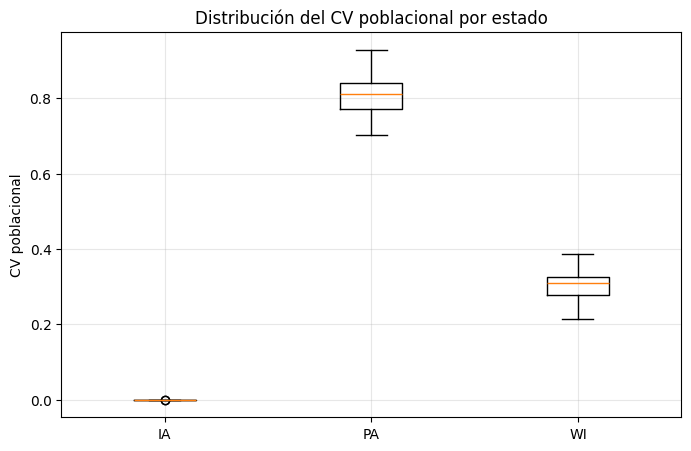

In [19]:
# =========================================================
# BOXPLOT CV
# =========================================================

plt.figure(figsize=(8, 5))

plt.boxplot([
    df_ia["pop_distrito_cv"],
    df_pa["pop_distrito_cv"],
    df_wi["pop_distrito_cv"],
])

plt.xticks([1, 2, 3], ["IA", "PA", "WI"])
plt.ylabel("CV poblacional")
plt.title("Distribución del CV poblacional por estado")
plt.grid(alpha=0.3)

plt.show()

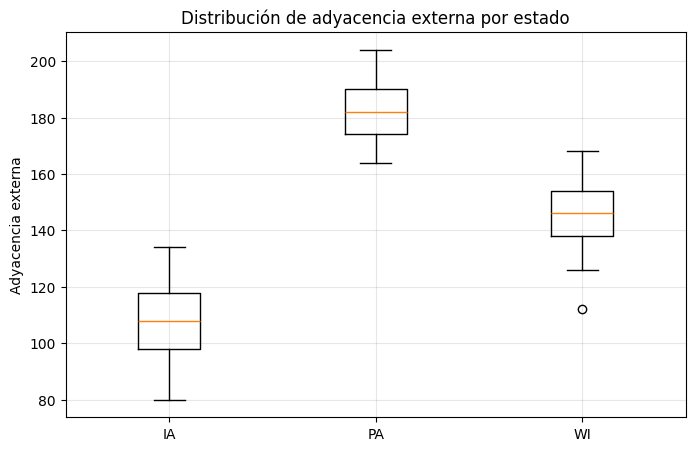

In [20]:
# =========================================================
# BOXPLOT ADYACENCIA
# =========================================================

plt.figure(figsize=(8, 5))

plt.boxplot([
    df_ia["ady_externa"],
    df_pa["ady_externa"],
    df_wi["ady_externa"],
])

plt.xticks([1, 2, 3], ["IA", "PA", "WI"])
plt.ylabel("Adyacencia externa")
plt.title("Distribución de adyacencia externa por estado")
plt.grid(alpha=0.3)

plt.show()

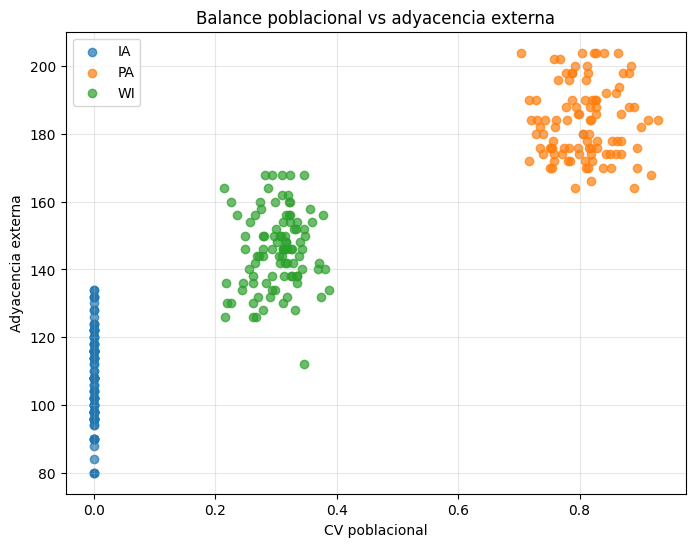

In [21]:
# =========================================================
# SCATTER CV VS ADYACENCIA
# =========================================================

plt.figure(figsize=(8, 6))

for estado, df in [
    ("IA", df_ia),
    ("PA", df_pa),
    ("WI", df_wi),
]:
    plt.scatter(
        df["pop_distrito_cv"],
        df["ady_externa"],
        label=estado,
        alpha=0.7
    )

plt.xlabel("CV poblacional")
plt.ylabel("Adyacencia externa")
plt.title("Balance poblacional vs adyacencia externa")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
import pandas as pd
import geopandas as gpd

ruta_gdf = "C:/Tesis/Códigos/DataEEUU/pa_paper/nodes.geojson"
ruta_asignaciones = "C:/Tesis/Códigos/resultados_eeuu/pa_sys/t_011/t_011_asignaciones.csv"

df = pd.read_csv(ruta_asignaciones)

df = df[df["x"] > 1e-6].copy()

df["comuna"] = df["i"].astype(str).str.strip().str.lower()
df["centro"] = df["j"].astype(str).str.strip().str.lower()

df = (
    df.sort_values("x", ascending=False)
      .drop_duplicates("comuna")
      [["comuna", "centro"]]
)

gdf = gpd.read_file(ruta_gdf)
gdf["comuna"] = (
        gdf["county"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )


gdf = gdf.merge(df, on="comuna", how="left")

In [26]:
queen_pa = construir_queen_adjacency(gdf)
rook_pa = construir_rook_adjacency(gdf)

In [27]:
print(
    "Queen:",
    sum(len(v) for v in queen_pa.values()) // 2
)

print(
    "Rook:",
    sum(len(v) for v in rook_pa.values()) // 2
)

Queen: 171
Rook: 167


In [5]:
BASE = r"C:\Tesis\Códigos"

df_ia = analizar_estado(
    "IA",
    os.path.join(BASE, "resultados_eeuu", "ia_sys"),
    os.path.join(BASE, "DataEEUU", "ia_paper", "nodes.geojson")
)

df_pa = analizar_estado(
    "PA",
    os.path.join(BASE, "resultados_eeuu", "pa_sys"),
    os.path.join(BASE, "DataEEUU", "pa_paper", "nodes.geojson")
)

df_wi = analizar_estado(
    "WI",
    os.path.join(BASE, "resultados_eeuu", "wi_sys"),
    os.path.join(BASE, "DataEEUU", "wi_paper", "nodes.geojson")
)

df_todos = pd.concat([df_ia, df_pa, df_wi], ignore_index=True)

In [7]:
tabla_resumen = (
    df_todos
    .groupby("estado")
    .agg(
        n_mapas=("mapa", "count"),
        cv_mean=("pop_cv", "mean"),
        cv_min=("pop_cv", "min"),
        cv_max=("pop_cv", "max"),
        ady_rook_mean=("ady_rook", "mean"),
        ady_rook_min=("ady_rook", "min"),
        ady_rook_max=("ady_rook", "max"),
        ady_queen_mean=("ady_queen", "mean"),
        ady_queen_min=("ady_queen", "min"),
        ady_queen_max=("ady_queen", "max"),
    )
    .reset_index()
)

display(tabla_resumen)

,estado,n_mapas,cv_mean,cv_min,cv_max,ady_rook_mean,ady_rook_min,ady_rook_max,ady_queen_mean,ady_queen_min,ady_queen_max
0,IA,100,0.000062,0.000015,0.000106,108.18,80,134,154.36,112,204
1,PA,100,0.808145,0.702919,0.928468,183.40,164,204,189.68,170,212
2,WI,100,0.302760,0.214570,0.387522,145.72,112,168,157.72,118,186


In [8]:
def top_estado(df, top=10):
    aux = df.copy()
    aux["rank_cv"] = aux["pop_cv"].rank()
    aux["rank_rook"] = aux["ady_rook"].rank()
    aux["score"] = aux["rank_cv"] + aux["rank_rook"]

    return (
        aux.sort_values(["score", "pop_cv", "ady_rook"])
           .head(top)
    )

top_global = (
    df_todos
    .groupby("estado", group_keys=False)
    .apply(lambda x: top_estado(x, top=10))
)

display(top_global)

C:\Users\andre\AppData\Local\Temp\ipykernel_20532\2755222061.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: top_estado(x, top=10))


,n_distritos,pop_mean,pop_std,pop_min,pop_max,pop_rango,pop_cv,ady_queen,ady_rook,estado,mapa,rank_cv,rank_rook,score
51,4,797592.250000,24.984995,797557.0,797616.0,59.0,0.000031,134,90,IA,t_052,9.0,8.0,17.0
65,4,797592.250000,24.984995,797557.0,797616.0,59.0,0.000031,134,90,IA,t_066,9.0,8.0,17.0
87,4,797592.250000,24.984995,797557.0,797616.0,59.0,0.000031,134,90,IA,t_088,9.0,8.0,17.0
36,4,797592.250000,22.455512,797562.0,797616.0,54.0,0.000028,142,98,IA,t_037,4.0,25.0,29.0
33,4,797592.250000,30.048572,797559.0,797632.0,73.0,0.000038,128,96,IA,t_034,14.0,16.5,30.5
18,4,797592.250000,11.898879,797576.0,797604.0,28.0,0.000015,132,100,IA,t_019,1.0,32.0,33.0
12,4,797592.250000,13.425722,797582.0,797612.0,30.0,0.000017,146,102,IA,t_013,3.0,37.5,40.5
93,4,797592.250000,42.002976,797539.0,797634.0,95.0,0.000053,146,96,IA,t_094,26.0,16.5,42.5
95,4,797592.250000,27.512119,797553.0,797617.0,64.0,0.000034,150,100,IA,t_096,12.5,32.0,44.5
76,4,797592.250000,35.938605,797565.0,797645.0,80.0,0.000045,154,100,IA,t_077,18.0,32.0,50.0
